# CS 6220: Homework 1
## Iris Flower Classification Using Logistic Regression

In this notebook, I use the Iris flower dataset to test my data mining setup by building and evaluating a Logistic Regression classification pipeline

### Workflow
- Load and inspect the Iris dataset
- Visualize the Iris features using a scatterplot
- Separate the input features and target class
- Split the dataset into 80% training data and 20% test data
- Build a scikit-learn pipeline using StandardScaler and Logistic Regression
- Train the classification model
- Make predictions on the test data
- Measure training and testing runtime
- Report prediction accuracy
- Explore Logistic Regression hyperparameters and compare their effect on accuracy
- Report the confusion matrix

In [1]:
# Import the libraries needed for data loading, visualization, modeling, and evaluation
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Environment Setup

I am using Python with Jupyter Notebook on my local laptop. The machine learning pipeline is implemented using scikit-learn.

In [2]:
# Display the main software versions used in this notebook
import sys
import sklearn

print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)
print("Scikit-Learn version:", sklearn.__version__)

Python version: 3.13.5
Pandas version: 3.0.0
Scikit-Learn version: 1.8.0


## Load and Inspect the Iris Dataset

The Iris dataset contains four numerical input features: sepal length, sepal width, petal length, and petal width. The target column represents the Iris flower class.

In [3]:
# Define column names because the downloaded iris.data file does not contain a header row
column_names = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

# Load the Iris dataset from the local file
iris_df = pd.read_csv("iris.data", header=None, names=column_names)

# Display the first five rows
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Inspect the dataset size, missing values, and class distribution
print("Dataset shape:", iris_df.shape)

print("\nMissing values:")
print(iris_df.isnull().sum())

print("\nClass distribution:")
print(iris_df["class"].value_counts())

Dataset shape: (150, 5)

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

Class distribution:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## Iris Data Visualization

The scatterplot below compares petal length and petal width for the three Iris classes.

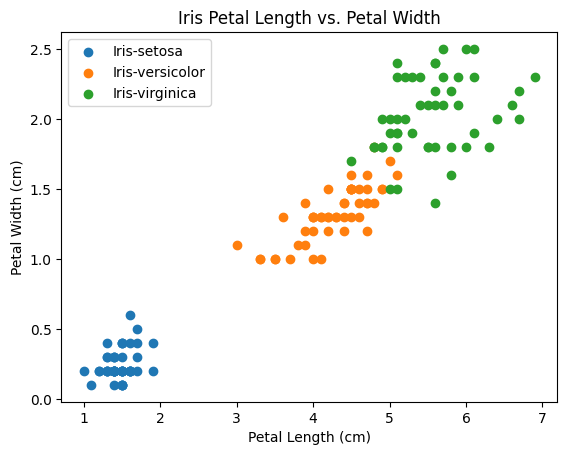

In [5]:
# Visualize petal length and petal width for each Iris class
for flower_class in iris_df["class"].unique():
    class_data = iris_df[iris_df["class"] == flower_class]
    plt.scatter(
        class_data["petal_length"],
        class_data["petal_width"],
        label=flower_class
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Petal Length vs. Petal Width")
plt.legend()
plt.show()

## Split into Training and Test Data

The four numerical measurements are used as input features, while the Iris class is used as the target. I split the dataset into 80% training data and 20% test data.

In [6]:
# Separate the four input features from the target class
X = iris_df[
    ["sepal_length", "sepal_width", "petal_length", "petal_width"]
]
y = iris_df["class"]

# Split the dataset into 80% training data and 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verify the split sizes
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training samples: 120
Test samples: 30

Training class distribution:
class
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64

Test class distribution:
class
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


## Build and Train the Logistic Regression Model

I use a scikit-learn Pipeline to standardize the input features and train a Logistic Regression classifier. StandardScaler scales the numerical features before they are passed to the classifier.

In [7]:
# Build a pipeline with feature scaling and Logistic Regression
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=1000))
])

# Measure the model training time
start_train = time.perf_counter()

model.fit(X_train, y_train)

end_train = time.perf_counter()
training_time = end_train - start_train

print("Model training completed successfully.")
print(f"Training time: {training_time:.6f} seconds")

Model training completed successfully.
Training time: 0.010030 seconds


## Model Prediction and Accuracy

I use the trained Logistic Regression model to predict the classes of the 30 test samples. I also measure the prediction time and calculate the classification accuracy on the test data.

In [8]:
# Measure prediction time on the test data
start_test = time.perf_counter()

y_pred = model.predict(X_test)

end_test = time.perf_counter()
testing_time = end_test - start_test

# Calculate test accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Training time: {training_time:.6f} seconds")
print(f"Testing time: {testing_time:.6f} seconds")
print(f"Test accuracy: {accuracy:.4f}")
print(f"Test accuracy percentage: {accuracy * 100:.2f}%")

Training time: 0.010030 seconds
Testing time: 0.002602 seconds
Test accuracy: 0.9333
Test accuracy percentage: 93.33%


## Logistic Regression Hyperparameter Experiment

I explore the Logistic Regression hyperparameter C to examine how different regularization settings affect test accuracy. Smaller C values apply stronger regularization, while larger C values apply weaker regularization.

In [9]:
# Test different values of the Logistic Regression C hyperparameter
c_values = [0.01, 0.1, 1, 10, 100]
hyperparameter_results = []

for c in c_values:
    test_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logistic_regression", LogisticRegression(C=c, max_iter=1000))
    ])
    
    test_model.fit(X_train, y_train)
    test_predictions = test_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, test_predictions)
    
    hyperparameter_results.append({
        "C": c,
        "Test Accuracy": test_accuracy
    })

# Display the results as a table
results_df = pd.DataFrame(hyperparameter_results)
results_df["Accuracy (%)"] = results_df["Test Accuracy"] * 100

results_df

,C,Test Accuracy,Accuracy (%)
0,0.01,0.800000,80.000000
1,0.10,0.866667,86.666667
2,1.00,0.933333,93.333333
3,10.00,1.000000,100.000000
4,100.00,1.000000,100.000000


### Hyperparameter Results

The test accuracy increased as the value of C increased. With C = 0.01, the model achieved 80.00% accuracy, while C = 1 achieved 93.33%. The highest observed accuracy was 100.00% for both C = 10 and C = 100. On this train-test split, weaker regularization produced better classification performance.

## Confusion Matrix

The confusion matrix shows how the baseline Logistic Regression model classified each Iris class on the test data. Rows represent the actual classes and columns represent the predicted classes.

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


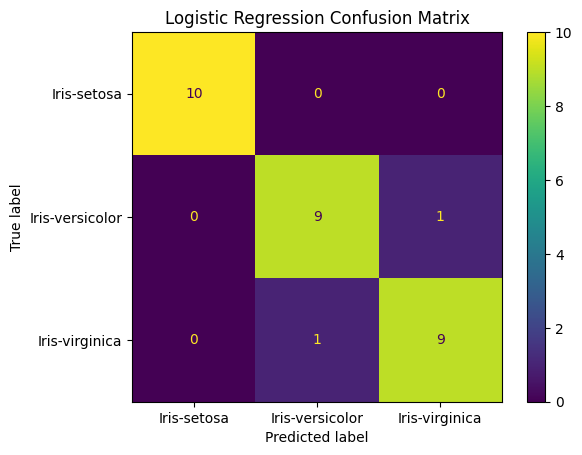

In [10]:
# Calculate the confusion matrix for the baseline model
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Confusion Matrix Results

The baseline Logistic Regression model correctly classified 28 of the 30 test samples. All 10 Iris-setosa samples were classified correctly. One Iris-versicolor sample was classified as Iris-virginica, and one Iris-virginica sample was classified as Iris-versicolor. This corresponds to the overall test accuracy of 93.33%.

## Final Results

The Logistic Regression model achieved a baseline test accuracy of 93.33% on the Iris dataset. In the hyperparameter experiment, increasing C improved the test accuracy, with C = 10 and C = 100 achieving 100% accuracy on this train-test split. The confusion matrix showed that the baseline model correctly classified 28 out of 30 test samples, with the two errors occurring between Iris-versicolor and Iris-virginica.

Overall, the experiment successfully demonstrates data loading, visualization, preprocessing, model training, prediction, runtime measurement, hyperparameter testing, and model evaluation using scikit-learn.